# Non Linear model: XGBoost

Offers better regulazation than Gradient Boosting

#### Score 12981

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import plotly.express as px
import seaborn as sns

# Load dataset
df = pd.read_csv('train.csv')  # Replace with your actual file path


# Select only object or category columns
cat_cols = df.select_dtypes(include=["object", "category"]).columns

# Fill NaN values in only those columns
df[cat_cols] = df[cat_cols].fillna("Missing")

## 1.1 convert types

In [32]:
df[['MSSubClass', 'MoSold', 'YearBuilt', 'YearRemodAdd', 'YrSold']] = df[['MSSubClass', 'MoSold', 'YearBuilt', 'YearRemodAdd', 'YrSold']].astype('object')

In [33]:
df = df.fillna(0)

C:\Users\berra\AppData\Local\Temp\ipykernel_7596\3475559988.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(0)


## 1.3 create variables (for interpretation)

In [34]:
df_dropped = df.copy()

#'YearBuilt', 'YearRemodAdd, 'MoSold', 'YrSold' convert to quantitative
# List of columns to convert
columns_to_convert = ['YearBuilt', 'YearRemodAdd', 'MoSold', 'YrSold']

# Convert each to integer safely
for col in columns_to_convert:
    df_dropped.loc[:, col] = df_dropped[col].astype(int)

# Set reference year
reference_year = df_dropped['YrSold'].max()

# Create quantitative features safely
df_dropped.loc[:, 'HouseAge'] = reference_year - df_dropped['YearBuilt']
df_dropped.loc[:, 'YearsSinceRemod'] = reference_year -df_dropped['YearRemodAdd']

df_dropped = df_dropped.drop([
    'YearBuilt', 'YearRemodAdd', 'YrSold', 'MoSold'
], axis=1) 

# Convert object columns to numeric, forcing errors to NaN
cols_to_convert = ['HouseAge', 'YearsSinceRemod']
df_dropped[cols_to_convert] = df_dropped[cols_to_convert].apply(pd.to_numeric, errors='coerce')

### Skewness

We can leave the skewness in exogen variables but we might want to normalise the SalePrice to get better predictions

## 1.4 cap outliers

In [35]:
# cap outliers
#outliers cap

num_features = [col for col in df_dropped.select_dtypes(include='number') if col != 'Id']
 
# Store the limits for each column
caps = {}

for col in num_features:
    q_low = df_dropped[col].quantile(0.01)
    q_high = df_dropped[col].quantile(0.99)
    
    # Save the thresholds
    caps[col] = (q_low, q_high)
    
    # Apply clipping
    df_dropped[col] = df_dropped[col].clip(lower=q_low, upper=q_high)



## RandomizedSearchCV

In [36]:
# # If needed:
# # pip install xgboost

# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import OneHotEncoder

# X = df_dropped.drop(['Id','SalePrice'],axis=1)
# y = df_dropped.SalePrice

# # Categorical columns
# categorical_cols = [cname for cname in X.columns if X[cname].dtype == "object"]

# # Preprocessing for categorical data
# categorical_transformer = Pipeline(steps=[
#     ('onehot', OneHotEncoder(handle_unknown='ignore'))  # returns sparse by default (fine for XGB)
# ])

# # Bundle preprocessing for numerical and categorical data
# preprocessor = ColumnTransformer(
#     transformers=[
#         ('cat', categorical_transformer, categorical_cols)
#     ],
#     remainder='passthrough'  # keep numerical columns
# )

# import pandas as pd
# from xgboost import XGBRegressor
# from sklearn.model_selection import train_test_split, RandomizedSearchCV
# from sklearn.metrics import mean_squared_error
# import numpy as np

# # Train-test split
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=1)

# # Pipeline with XGBoost
# pipeline_XGB = Pipeline(steps=[
#     ('preprocessor', preprocessor),
#     ('model', XGBRegressor(
#         random_state=1,
#         objective='reg:squarederror',
#         tree_method='hist',   # fast, CPU-friendly
#         n_jobs=-1
#     ))
# ])

# # Parameter grid for XGBoost
# param_grid = {
#     'model__n_estimators': [300, 500, 800, 1200],
#     'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
#     'model__max_depth': [3, 4, 6, 8, 10],
#     'model__subsample': [0.6, 0.8, 1.0],
#     'model__colsample_bytree': [0.6, 0.8, 1.0],
#     'model__min_child_weight': [1, 3, 5, 7],
#     'model__reg_alpha': [0.0, 0.01, 0.1, 1.0],
#     'model__reg_lambda': [0.1, 1.0, 10.0],
#     # 'model__gamma': [0, 0.1, 0.2]  # optional additional regularization
# }

# # RandomizedSearchCV
# random_search = RandomizedSearchCV(
#     estimator=pipeline_XGB,
#     param_distributions=param_grid,
#     n_iter=20,
#     cv=5,
#     scoring='neg_mean_squared_error',
#     verbose=1,
#     random_state=1,
#     n_jobs=-1
# )

# # Fit
# random_search.fit(X_train, y_train)

# # Evaluate best model
# best_model = random_search.best_estimator_
# y_pred = best_model.predict(X_test)

# # (Optional) report RMSE
# rmse = mean_squared_error(y_test, y_pred, squared=False)
# print("Best params:", random_search.best_params_)
# print("Test RMSE:", rmse)


## GridSearchCV

In [37]:
# from sklearn.model_selection import GridSearchCV

# # Refined grid around the best values
# param_grid = {
#    'model__n_estimators': [700, 800, 900],
#     'model__learning_rate': [0.01, 0.02, 0.03],
#     'model__max_depth': [3, 4, 5],
#     'model__subsample': [0.7, 0.8, 0.9],
#     'model__colsample_bytree': [0.7, 0.8, 0.9],
#     'model__min_child_weight': [1, 2, 3],
#     'model__reg_alpha': [0.0, 0.01, 0.02],
#     'model__reg_lambda': [0.5, 1.0, 3],

# }

# # Initialize GridSearchCV
# grid_search = GridSearchCV(
#     estimator=best_model,
#     param_grid=param_grid,
#     cv=5,
#     scoring='neg_mean_squared_error',
#     verbose=1,
#     n_jobs=-1
# )

# # Fit to training data
# grid_search.fit(X_train, y_train)

# # Evaluate best model
# best_model = grid_search.best_estimator_
# y_pred = best_model.predict(X_test)
# mse = mean_squared_error(y_test, y_pred)
# rmse = np.sqrt(mse)

# print("Best Parameters from Grid Search:")
# print(grid_search.best_params_)
# print(f"Test RMSE: {rmse:.2f}")

## best model from RandomSearch + GridSearchCV

The tuning is time consuming (one of the downsides of the model since we have many parameters), this is the best model we found

In [38]:
# If needed:
# pip install xgboost

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

X = df_dropped.drop(['Id','SalePrice'],axis=1)
y = df_dropped.SalePrice


# Categorical columns
categorical_cols = [cname for cname in X.columns if X[cname].dtype == "object"]

# Preprocessing for categorical data
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))  # returns sparse by default (fine for XGB)
])

# Bundle preprocessing for numerical and categorical data
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='passthrough'  # keep numerical columns
)

import pandas as pd
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_squared_error
import numpy as np

xgbr = XGBRegressor(
    random_state=1,
    objective="reg:squarederror",
    tree_method="hist",   # fast, CPU-friendly
    n_jobs=-1,
    # Best params
    colsample_bytree=0.9,
    learning_rate=0.03,
    max_depth=3,
    min_child_weight=1,
    n_estimators=900,
    reg_alpha=0.02,
    reg_lambda=0.5,
    subsample=0.9,
)


# Pipeline with XGBoost
pipeline_XGB = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', xgbr)
])

# # Fit to training data
pipeline_XGB.fit(X, y)

C:\Users\berra\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1623: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['MSZoning', 'Street',
                                                   'Alley', 'LotShape',
                                                   'LandContour', 'Utilities',
                                                   'LotConfig', 'LandSlope',
                                                   'Neighborhood', 'Condition1',
                                                   'Condition2', 'BldgType',
                                                   'HouseStyle', 'RoofStyle',
                                                   'RoofMatl', 'Exterior...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.03,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=3, max_leaves=None, min_child_weight=1,
                              missing=nan, monotone_constraints=None,
                              multi_strategy=None, n_estimators=900, n_jobs=-1,
                              num_parallel_tree=None, ...))])

Using scoring='r2'


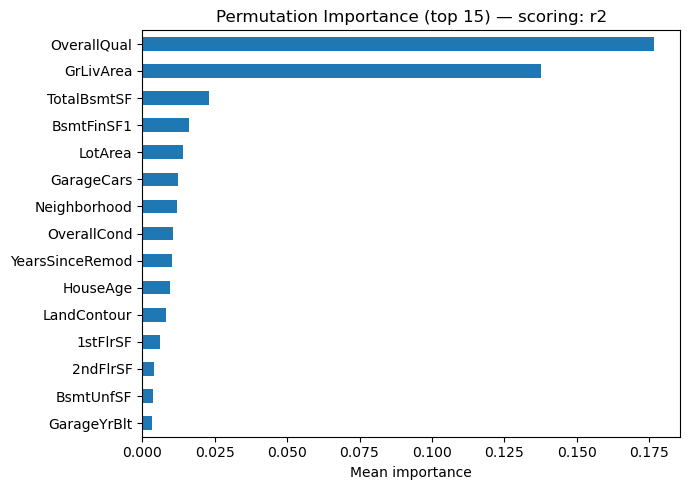

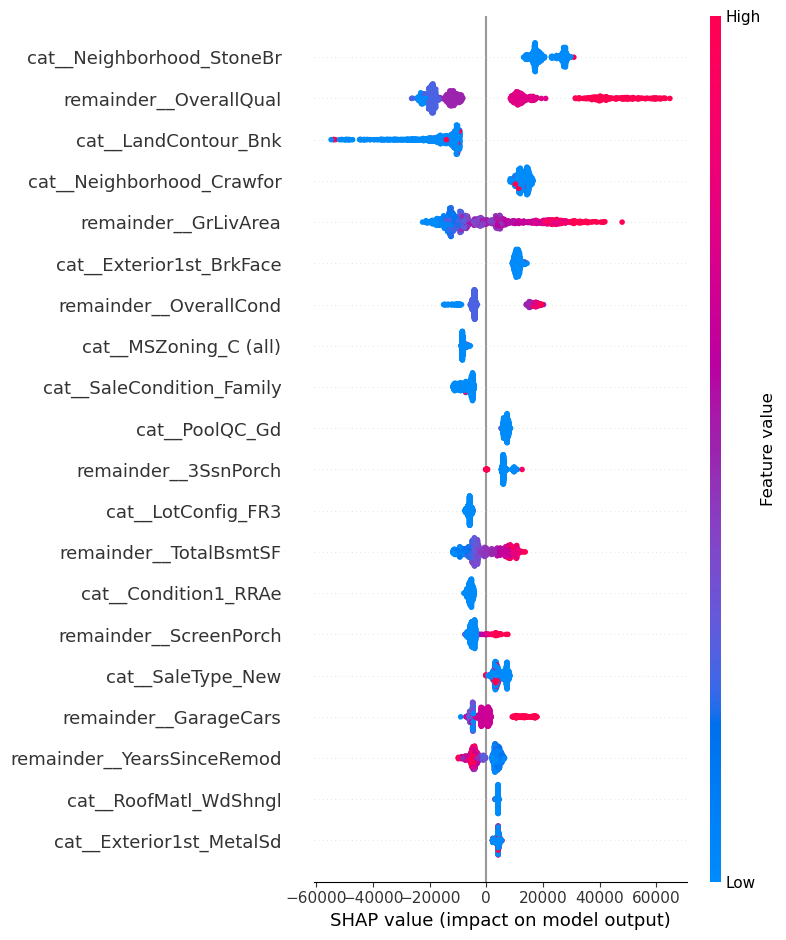

In [43]:
# ==========================
# Two quick analyses: 
# Permutation Importance + SHAP
# ==========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
from sklearn.base import is_classifier
from sklearn.utils.multiclass import type_of_target

# ---- Helper: pick scoring automatically ----
def infer_scoring(pipeline, X, y):
    target_type = type_of_target(y)
    if target_type in ("continuous", "continuous-multioutput"):
        return "r2"   # regression
    if is_classifier(pipeline):
        if hasattr(pipeline, "predict_proba") or hasattr(pipeline, "decision_function"):
            # binary vs multiclass
            try:
                n_classes = len(pipeline.classes_)
            except Exception:
                n_classes = 2
            return "roc_auc" if n_classes <= 2 else "roc_auc_ovr"
        return "accuracy"
    return "r2"

# ---- 1) Permutation Importance ----
scoring = infer_scoring(pipeline_XGB, X, y)
print(f"Using scoring='{scoring}'")

perm = permutation_importance(
    pipeline_XGB, X, y,
    n_repeats=10, random_state=42, n_jobs=-1,
    scoring=scoring
)

perm_importances = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(7,5))
perm_importances.head(15).iloc[::-1].plot(kind="barh")
plt.title(f"Permutation Importance (top 15) — scoring: {scoring}")
plt.xlabel("Mean importance")
plt.tight_layout()
plt.show()

# ---- 2) SHAP Summary Plot ----
import shap

# Take a sample for speed if large
X_sample = X.sample(min(1000, len(X)), random_state=42) if hasattr(X, "sample") else X

pre = pipeline_XGB.named_steps["preprocessor"]
model = pipeline_XGB.named_steps["model"]

X_trans = pre.transform(X_sample)
try:
    X_trans = X_trans.toarray()  # if sparse
except Exception:
    pass

try:
    feature_names = pre.get_feature_names_out()
except Exception:
    feature_names = [f"f{i}" for i in range(X_trans.shape[1])]

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_trans)

if isinstance(shap_values, list):  # multiclass
    shap_abs = np.mean([np.abs(sv) for sv in shap_values], axis=0)
    shap.summary_plot(shap_abs, X_trans, feature_names=feature_names, show=True)
else:  # regression or binary classification
    shap.summary_plot(shap_values, X_trans, feature_names=feature_names, show=True)


# Test set

In [ ]:
d_test = pd.read_csv('test.csv') 

## 2.1 convert types

In [ ]:
d_test[['MSSubClass', 'MoSold', 'YearBuilt', 'YearRemodAdd', 'YrSold']] = d_test[['MSSubClass', 'MoSold', 'YearBuilt', 'YearRemodAdd', 'YrSold']].astype('object')

In [ ]:
# Select only object or category columns
cat_cols = d_test.select_dtypes(include=["object", "category"]).columns

# Fill NaN values in only those columns
d_test[cat_cols] = d_test[cat_cols].fillna("Missing")

## 2.2 fill na 

In [ ]:
# Imputation dans le test set (numeric)
d_test.fillna(0, inplace=True)

## 2.3 create variables

In [ ]:
#'YearBuilt', 'YearRemodAdd, 'MoSold', 'YrSold' convert to quantitative
# List of columns to convert
columns_to_convert = ['YearBuilt', 'YearRemodAdd', 'MoSold', 'YrSold']

# Convert each to integer safely
for col in columns_to_convert:
    d_test.loc[:, col] = d_test[col].astype(int)

# Set reference year
reference_year = d_test['YrSold'].max()

# Create quantitative features safely
d_test.loc[:, 'HouseAge'] = reference_year - d_test['YearBuilt']
d_test.loc[:, 'YearsSinceRemod'] = reference_year - d_test['YearRemodAdd']


d_test = d_test.drop([
    'YearBuilt', 'YearRemodAdd', 'YrSold', 'MoSold'
], axis=1) 

# Convert object columns to numeric, forcing errors to NaN
cols_to_convert = ['HouseAge', 'YearsSinceRemod']
d_test[cols_to_convert] = d_test[cols_to_convert].apply(pd.to_numeric, errors='coerce')

## 2.4 cap outliers

In [ ]:
num_features = [col for col in num_features if col != "SalePrice"]

for col in num_features:
    q_low, q_high = caps[col]
    d_test[col] = d_test[col].clip(lower=q_low, upper=q_high)


## 2.5 Predict

In [ ]:
# One-hot encode test set
X_test = d_test.drop(['Id'],axis=1)

y_pred = pipeline_XGB.predict(X_test)

d_test['SalePrice'] = y_pred
d_test[['Id', 'SalePrice']].to_csv("predictions_XGB.csv", index=False)